<a href="https://colab.research.google.com/github/jayakumar2811/AI-POWERED-JOB-MARKET-INTELLIGENCE-AND-SALARY-PREDICTION-SYSTEM-USING-NLP-AND-MACHINE-LEARNING./blob/main/Copy_of_PG_Final_year_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# DATA COLLECTION MODULE
# AI JOB MARKET INTELLIGENCE SYSTEM
# ============================================================

import pandas as pd
import os
import datetime

# ==============================
# LOGGER FUNCTION
# ==============================

def log(message):
    """
    Simple logger to track module execution
    """
    time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{time}] {message}")


# ==============================
# CONFIGURATION
# ==============================

DATA_PATH = "/content/jobs_data_final.csv"
PROCESSED_PATH = "collected_data.csv"


# ==============================
# CHECK FILE EXISTENCE
# ==============================

def check_file_exists(path):
    """
    Check if dataset file exists
    """
    if os.path.exists(path):
        log(f"Dataset found at: {path}")
        return True
    else:
        log(f"Dataset NOT found at: {path}")
        return False


# ==============================
# LOAD DATASET
# ==============================

def load_dataset(path):
    """
    Load dataset using pandas
    """
    try:
        df = pd.read_csv(path)
        log("Dataset loaded successfully")
        log(f"Dataset shape: {df.shape}")
        return df
    except Exception as e:
        log(f"Error loading dataset: {e}")
        return None


# ==============================
# DISPLAY BASIC INFO
# ==============================

def show_basic_info(df):
    """
    Display dataset structure
    """
    log("Displaying dataset information")

    print("\n===== HEAD =====")
    print(df.head())

    print("\n===== INFO =====")
    print(df.info())

    print("\n===== DESCRIPTION =====")
    print(df.describe())


# ==============================
# VALIDATE DATASET
# ==============================

def validate_dataset(df):
    """
    Check if required columns exist
    """
    required_columns = [
        "Job Title",
        "Job Description",
        "Salary",
        "Years of Experience"
    ]

    log("Validating dataset columns...")

    for col in required_columns:
        if col not in df.columns:
            log(f"Missing column: {col}")
            return False

    log("All required columns are present")
    return True


# ==============================
# SAVE CLEAN COPY
# ==============================

def save_dataset(df, path):
    """
    Save dataset for next modules
    """
    try:
        df.to_csv(path, index=False)
        log(f"Dataset saved to {path}")
    except Exception as e:
        log(f"Error saving dataset: {e}")


# ==============================
# MAIN DATA COLLECTION FUNCTION
# ==============================

def run_data_collection():
    """
    Complete data collection pipeline
    """

    log("Starting Data Collection Module")

    # Step 1: Check file
    if not check_file_exists(DATA_PATH):
        log("Please download dataset from Kaggle and place in project folder")
        return

    # Step 2: Load dataset
    df = load_dataset(DATA_PATH)

    if df is None:
        log("Failed to load dataset")
        return

    # Step 3: Show info
    show_basic_info(df)

    # Step 4: Validate dataset
    if not validate_dataset(df):
        log("Dataset validation failed")
        return

    # Step 5: Save copy
    save_dataset(df, PROCESSED_PATH)

    log("Data Collection Module Completed Successfully")


# ==============================
# RUN MODULE
# ==============================

if __name__ == "__main__":
    run_data_collection()

[2026-05-17 08:09:07] Starting Data Collection Module
[2026-05-17 08:09:07] Dataset NOT found at: /content/jobs_data_final.csv
[2026-05-17 08:09:07] Please download dataset from Kaggle and place in project folder


In [ ]:
# ============================================================
# DATA PREPROCESSING MODULE
# AI JOB MARKET INTELLIGENCE SYSTEM
# ============================================================

import pandas as pd
import numpy as np
import re
import datetime
from sklearn.preprocessing import MinMaxScaler

# ==============================
# LOGGER FUNCTION
# ==============================

def log(message):
    time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{time}] {message}")


# ==============================
# CONFIGURATION
# ==============================

INPUT_FILE = "collected_data.csv"
OUTPUT_FILE = "preprocessed_data.csv"


# ==============================
# LOAD DATA
# ==============================

def load_data(path):
    try:
        df = pd.read_csv(path)
        log(f"Dataset loaded: {df.shape}")
        return df
    except Exception as e:
        log(f"Error loading file: {e}")
        return None


# ==============================
# REMOVE DUPLICATES
# ==============================

def remove_duplicates(df):
    before = df.shape[0]
    df = df.drop_duplicates()
    after = df.shape[0]

    log(f"Removed {before - after} duplicate rows")
    return df


# ==============================
# HANDLE MISSING VALUES
# ==============================

def handle_missing_values(df):
    log("Handling missing values")

    print("\nMissing values before:\n", df.isnull().sum())

    # Fill or drop missing values
    df = df.dropna()

    print("\nMissing values after:\n", df.isnull().sum())

    return df


# ==============================
# CLEAN TEXT DATA
# ==============================

def clean_text(text):
    """
    Clean text for NLP
    """
    text = str(text).lower()                    # lowercase
    text = re.sub(r'[^a-zA-Z ]', '', text)      # remove special chars
    text = re.sub(r'\s+', ' ', text)            # remove extra spaces
    return text.strip()


def clean_text_columns(df):
    log("Cleaning text columns")

    text_columns = ["Job Title", "Job Description"]

    for col in text_columns:
        if col in df.columns:
            df[col] = df[col].apply(clean_text)

    return df


# ==============================
# REMOVE OUTLIERS
# ==============================

def remove_outliers(df):
    log("Removing outliers using IQR method")

    if "Salary" in df.columns:
        Q1 = df["Salary"].quantile(0.25)
        Q3 = df["Salary"].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        before = df.shape[0]
        df = df[(df["Salary"] >= lower) & (df["Salary"] <= upper)]
        after = df.shape[0]

        log(f"Removed {before - after} outliers")

    return df


# ==============================
# NORMALIZE NUMERICAL DATA
# ==============================

def normalize_data(df):
    log("Normalizing numerical columns")

    scaler = MinMaxScaler()

    numeric_cols = ["Age", "Years of Experience", "Salary"]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = scaler.fit_transform(df[[col]])

    return df


# ==============================
# ENCODE BASIC CATEGORICAL DATA
# ==============================

def encode_basic(df):
    log("Encoding categorical columns")

    if "Gender" in df.columns:
        df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

    return df


# ==============================
# SAVE PROCESSED DATA
# ==============================

def save_data(df, path):
    try:
        df.to_csv(path, index=False)
        log(f"Processed data saved to {path}")
    except Exception as e:
        log(f"Error saving file: {e}")


# ==============================
# MAIN PREPROCESSING PIPELINE
# ==============================

def run_preprocessing():
    log("Starting Data Preprocessing Module")

    df = load_data(INPUT_FILE)

    if df is None:
        log("No data to process")
        return

    # Step 1: Remove duplicates
    df = remove_duplicates(df)

    # Step 2: Handle missing values
    df = handle_missing_values(df)

    # Step 3: Clean text
    df = clean_text_columns(df)

    # Step 4: Remove outliers
    df = remove_outliers(df)

    # Step 5: Normalize data
    df = normalize_data(df)

    # Step 6: Encode basic categorical
    df = encode_basic(df)

    # Step 7: Save output
    save_data(df, OUTPUT_FILE)

    log("Data Preprocessing Completed Successfully")


# ==============================
# RUN MODULE
# ==============================

if __name__ == "__main__":
    run_preprocessing()

[2026-05-04 17:25:44] Starting Data Preprocessing Module
[2026-05-04 17:25:44] Dataset loaded: (375, 8)
[2026-05-04 17:25:44] Removed 3 duplicate rows
[2026-05-04 17:25:44] Handling missing values

Missing values before:
 Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
Job Description        0
Location               0
dtype: int64

Missing values after:
 Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
Job Description        0
Location               0
dtype: int64
[2026-05-04 17:25:44] Cleaning text columns
[2026-05-04 17:25:44] Removing outliers using IQR method
[2026-05-04 17:25:44] Removed 0 outliers
[2026-05-04 17:25:44] Normalizing numerical columns
[2026-05-04 17:25:44] Encoding categorical columns
[2026-05-04 17:25:44] Processed data saved to preprocessed_data.csv
[2026-05-04 17:

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import joblib

# Load your preprocessed data
df = pd.read_csv("collected_data.csv")

# Fit a MinMaxScaler on the Salary column
scaler = MinMaxScaler()
scaler.fit(df[["Salary"]])

# Save the scaler to use in Streamlit
joblib.dump(scaler, "salary_scaler.pkl")
print("salary_scaler.pkl created successfully!")

salary_scaler.pkl created successfully!


In [ ]:
# ============================================================
# NLP SKILL EXTRACTION MODULE
# AI JOB MARKET INTELLIGENCE SYSTEM
# ============================================================

import pandas as pd
import re
import nltk
import datetime

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# ==============================
# LOGGER
# ==============================

def log(message):
    time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{time}] {message}")


# ==============================
# CONFIGURATION
# ==============================

INPUT_FILE = "preprocessed_data.csv"
OUTPUT_FILE = "skills_extracted.csv"


# ==============================
# SKILL DATABASE
# ==============================

SKILL_DB = [
    "python", "java", "c++", "sql", "mysql",
    "machine learning", "deep learning", "nlp",
    "data analysis", "data science",
    "pandas", "numpy", "tensorflow", "keras",
    "excel", "power bi", "tableau"
]


# ==============================
# TEXT CLEANING
# ==============================

def clean_text(text):
    text = str(text).lower()                    # lowercase
    text = re.sub(r'[^a-zA-Z ]', '', text)      # remove special chars
    text = re.sub(r'\s+', ' ', text)            # remove extra spaces
    return text.strip()


# ==============================
# TOKENIZATION
# ==============================

def tokenize_text(text):
    return word_tokenize(text)


# ==============================
# REMOVE STOPWORDS
# ==============================

def remove_stopwords(tokens):
    stop_words = set(stopwords.words("english"))
    return [word for word in tokens if word not in stop_words]


# ==============================
# N-GRAM GENERATION
# ==============================

def generate_ngrams(tokens):
    """
    Generate unigrams + bigrams
    """
    unigrams = tokens
    bigrams = [" ".join([tokens[i], tokens[i+1]]) for i in range(len(tokens)-1)]
    return unigrams + bigrams


# ==============================
# SKILL EXTRACTION FUNCTION
# ==============================

def extract_skills(text):
    """
    Extract skills using keyword matching + n-grams
    """

    text = clean_text(text)

    tokens = tokenize_text(text)
    tokens = remove_stopwords(tokens)

    all_terms = generate_ngrams(tokens)

    found_skills = []

    for skill in SKILL_DB:
        if skill in all_terms or skill in text:
            found_skills.append(skill)

    return list(set(found_skills))


# ==============================
# PROCESS DATASET
# ==============================

def process_dataset(df):
    """
    Apply skill extraction to dataset
    """

    log("Extracting skills from dataset...")

    skills_list = []

    for index, row in df.iterrows():

        # Combine job title + description
        text = ""

        if "Job Title" in df.columns:
            text += str(row["Job Title"]) + " "

        if "Job Description" in df.columns:
            text += str(row["Job Description"])

        skills = extract_skills(text)

        skills_list.append(", ".join(skills))

    df["Extracted Skills"] = skills_list

    return df


# ==============================
# LOAD DATA
# ==============================

def load_data(path):
    try:
        df = pd.read_csv(path)
        log(f"Data loaded: {df.shape}")
        return df
    except Exception as e:
        log(f"Error loading file: {e}")
        return None


# ==============================
# SAVE DATA
# ==============================

def save_data(df, path):
    try:
        df.to_csv(path, index=False)
        log(f"Saved to {path}")
    except Exception as e:
        log(f"Error saving file: {e}")


# ==============================
# TEST SINGLE TEXT (FOR DEMO)
# ==============================

def test_single_input():
    print("\n=== TEST SKILL EXTRACTION ===")
    text = input("Enter job description or resume: ")

    skills = extract_skills(text)

    print("Extracted Skills:", skills)


# ==============================
# MAIN FUNCTION
# ==============================

def run_nlp_module():

    log("Starting NLP Skill Extraction Module")

    df = load_data(INPUT_FILE)

    if df is None:
        log("No data available")
        return

    df = process_dataset(df)

    save_data(df, OUTPUT_FILE)

    log("Skill Extraction Completed Successfully")


# ==============================
# RUN MODULE
# ==============================

if __name__ == "__main__":

    run_nlp_module()

    # Optional: test manually
    test_single_input()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


[2026-05-04 17:25:54] Starting NLP Skill Extraction Module
[2026-05-04 17:25:54] Data loaded: (370, 8)
[2026-05-04 17:25:54] Extracting skills from dataset...
[2026-05-04 17:25:54] Saved to skills_extracted.csv
[2026-05-04 17:25:54] Skill Extraction Completed Successfully

=== TEST SKILL EXTRACTION ===
Enter job description or resume: python
Extracted Skills: ['python']


[2026-05-04 17:26:06] Starting EDA Module
[2026-05-04 17:26:06] Dataset loaded: (370, 9)
[2026-05-04 17:26:06] Generating dataset summary

===== HEAD =====
        Age  Gender Education Level          Job Title  Years of Experience  \
0  0.300000       0      Bachelor's  software engineer                 0.20   
1  0.166667       1        Master's       data analyst                 0.12   
2  0.733333       0             PhD     senior manager                 0.60   
3  0.433333       1      Bachelor's    sales associate                 0.28   
4  0.966667       0        Master's           director                 0.80   

     Salary                                    Job Description   Location  \
0  0.359103  looking for a software engineer with experienc...     Mumbai   
1  0.258963  seeking a skilled data analyst who has knowled...  Hyderabad   
2  0.599439  we are hiring a senior manager required skills...      Delhi   
3  0.238935  join our team as a sales associate must have e..

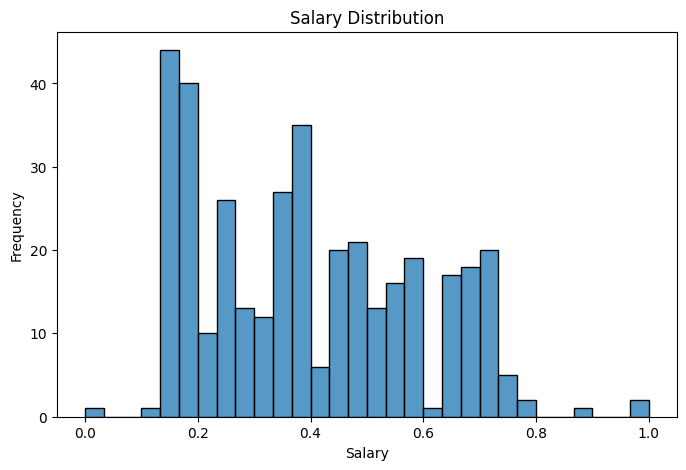

[2026-05-04 17:26:07] Plotting Experience vs Salary


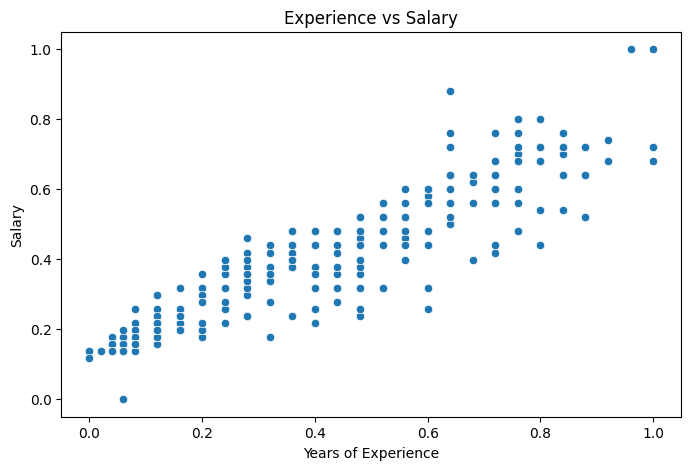

[2026-05-04 17:26:07] Analyzing Job Roles


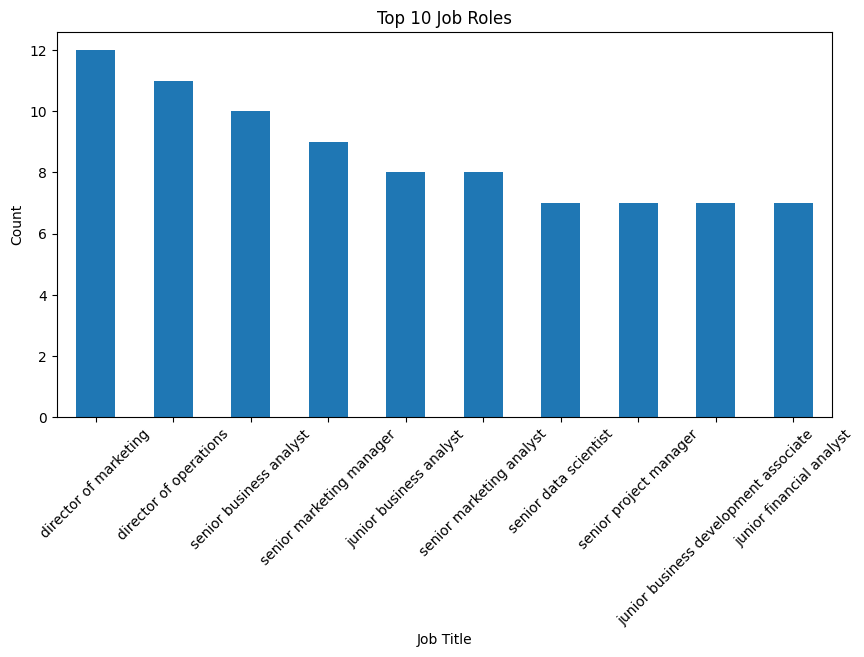

[2026-05-04 17:26:07] Analyzing Skill Demand


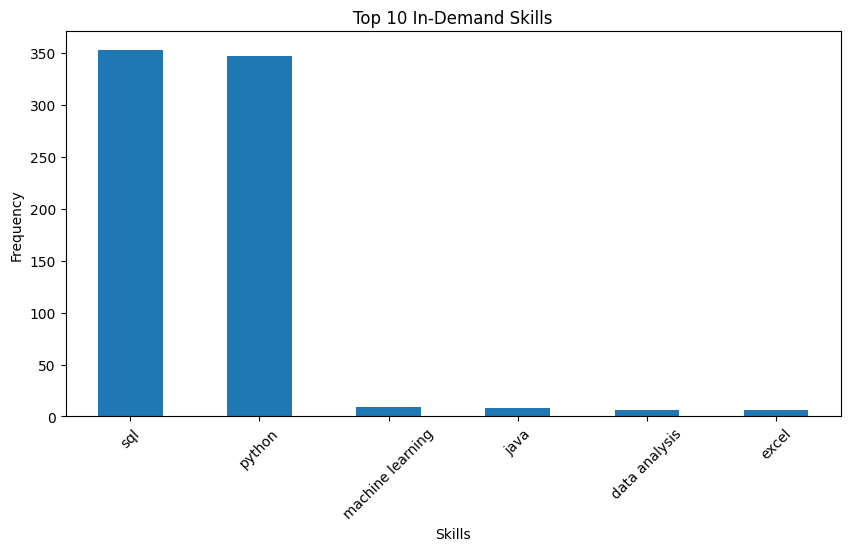

[2026-05-04 17:26:07] Generating Correlation Heatmap


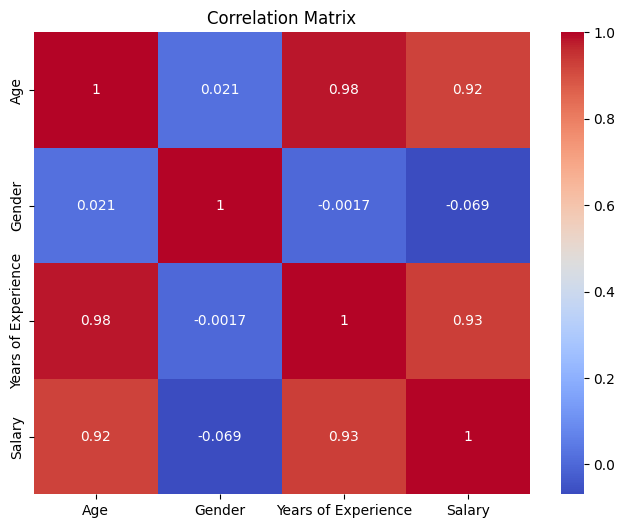

[2026-05-04 17:26:08] Analyzing Salary by Education Level


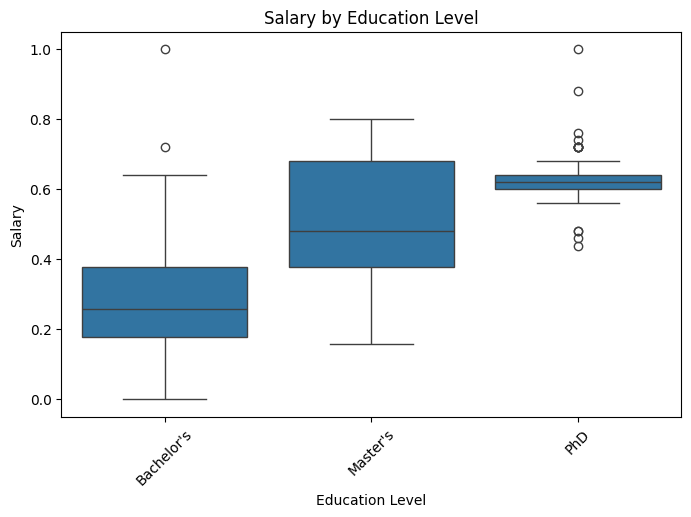

[2026-05-04 17:26:08] Analyzing Salary by Job Role


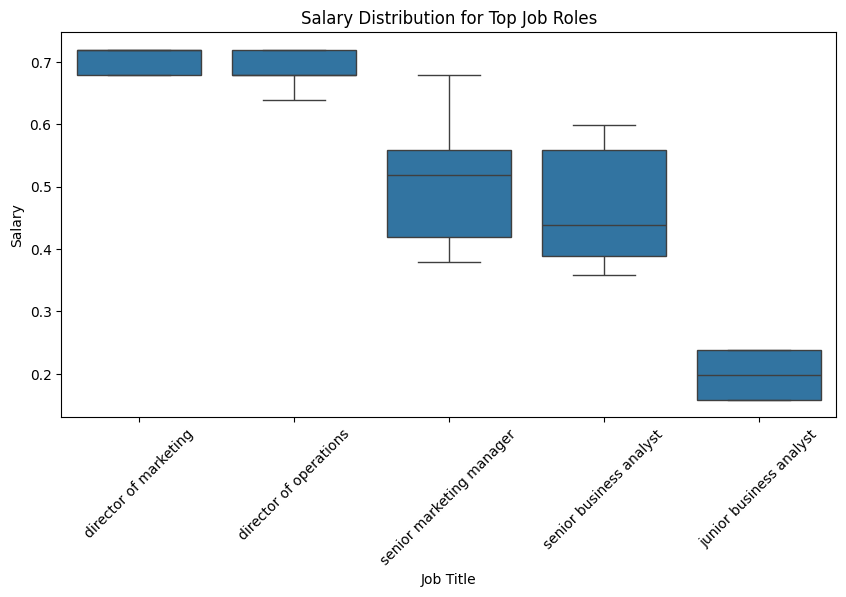

[2026-05-04 17:26:08] EDA Completed Successfully


In [ ]:
# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA) MODULE
# AI JOB MARKET INTELLIGENCE SYSTEM
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# ==============================
# LOGGER
# ==============================

def log(message):
    time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{time}] {message}")

# ==============================
# CONFIG
# ==============================

INPUT_FILE = "skills_extracted.csv"   # or skills_extracted_dynamic.csv


# ==============================
# LOAD DATA
# ==============================

def load_data(path):
    try:
        df = pd.read_csv(path)
        log(f"Dataset loaded: {df.shape}")
        return df
    except Exception as e:
        log(f"Error loading data: {e}")
        return None


# ==============================
# BASIC DATA SUMMARY
# ==============================

def data_summary(df):
    log("Generating dataset summary")

    print("\n===== HEAD =====")
    print(df.head())

    print("\n===== INFO =====")
    print(df.info())

    print("\n===== DESCRIPTION =====")
    print(df.describe())


# ==============================
# SALARY DISTRIBUTION
# ==============================

def salary_distribution(df):
    log("Plotting Salary Distribution")

    plt.figure(figsize=(8,5))
    sns.histplot(df["Salary"], bins=30)
    plt.title("Salary Distribution")
    plt.xlabel("Salary")
    plt.ylabel("Frequency")
    plt.show()


# ==============================
# EXPERIENCE VS SALARY
# ==============================

def experience_vs_salary(df):
    log("Plotting Experience vs Salary")

    plt.figure(figsize=(8,5))
    sns.scatterplot(
        x=df["Years of Experience"],
        y=df["Salary"]
    )
    plt.title("Experience vs Salary")
    plt.xlabel("Years of Experience")
    plt.ylabel("Salary")
    plt.show()


# ==============================
# JOB ROLE FREQUENCY
# ==============================

def job_role_frequency(df):
    log("Analyzing Job Roles")

    plt.figure(figsize=(10,5))
    df["Job Title"].value_counts().head(10).plot(kind="bar")
    plt.title("Top 10 Job Roles")
    plt.xlabel("Job Title")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()


# ==============================
# SKILL DEMAND ANALYSIS
# ==============================

def skill_demand(df):
    log("Analyzing Skill Demand")

    all_skills = []

    for skills in df["Extracted Skills"].dropna():
        skill_list = skills.split(",")
        all_skills.extend([s.strip() for s in skill_list])

    skill_counts = pd.Series(all_skills).value_counts().head(10)

    plt.figure(figsize=(10,5))
    skill_counts.plot(kind="bar")
    plt.title("Top 10 In-Demand Skills")
    plt.xlabel("Skills")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()


# ==============================
# CORRELATION HEATMAP
# ==============================

def correlation_analysis(df):
    log("Generating Correlation Heatmap")

    numeric_df = df.select_dtypes(include=['number'])

    plt.figure(figsize=(8,6))
    sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.show()


# ==============================
# SALARY BY EDUCATION
# ==============================

def salary_by_education(df):
    if "Education Level" not in df.columns:
        return

    log("Analyzing Salary by Education Level")

    plt.figure(figsize=(8,5))
    sns.boxplot(x=df["Education Level"], y=df["Salary"])
    plt.title("Salary by Education Level")
    plt.xticks(rotation=45)
    plt.show()


# ==============================
# SALARY BY JOB ROLE
# ==============================

def salary_by_job(df):
    log("Analyzing Salary by Job Role")

    top_jobs = df["Job Title"].value_counts().head(5).index
    subset = df[df["Job Title"].isin(top_jobs)]

    plt.figure(figsize=(10,5))
    sns.boxplot(x=subset["Job Title"], y=subset["Salary"])
    plt.title("Salary Distribution for Top Job Roles")
    plt.xticks(rotation=45)
    plt.show()


# ==============================
# MAIN EDA FUNCTION
# ==============================

def run_eda():

    log("Starting EDA Module")

    df = load_data(INPUT_FILE)

    if df is None:
        log("No data found")
        return

    # Step 1: Summary
    data_summary(df)

    # Step 2: Visualizations
    salary_distribution(df)
    experience_vs_salary(df)
    job_role_frequency(df)
    skill_demand(df)
    correlation_analysis(df)
    salary_by_education(df)
    salary_by_job(df)

    log("EDA Completed Successfully")


# ==============================
# RUN MODULE
# ==============================

if __name__ == "__main__":
    run_eda()

In [ ]:
# ============================================================
# FEATURE ENGINEERING MODULE
# AI JOB MARKET INTELLIGENCE SYSTEM
# ============================================================

import pandas as pd
import numpy as np
import datetime
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# ==============================
# LOGGER
# ==============================

def log(message):
    time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{time}] {message}")

# ==============================
# CONFIG
# ==============================

INPUT_FILE = "skills_extracted.csv"   # or previous module output
FEATURE_FILE = "features.npy"
TARGET_FILE = "target.npy"

TFIDF_MODEL_FILE = "tfidf_vectorizer.pkl"
ENCODER_FILE = "encoders.pkl"

# ==============================
# LOAD DATA
# ==============================

def load_data(path):
    try:
        df = pd.read_csv(path)
        log(f"Data loaded: {df.shape}")
        return df
    except Exception as e:
        log(f"Error loading file: {e}")
        return None

# ==============================
# LABEL ENCODING
# ==============================

def label_encode(df):
    log("Applying Label Encoding")

    encoders = {}

    categorical_cols = ["Gender", "Education Level"]

    for col in categorical_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            encoders[col] = le

    return df, encoders

# ==============================
# ONE-HOT ENCODING (OPTIONAL)
# ==============================

def one_hot_encode(df):
    log("Applying One-Hot Encoding (Job Title)")

    if "Job Title" in df.columns:
        df = pd.get_dummies(df, columns=["Job Title"])

    return df

# ==============================
# TEXT VECTORIZATION (TF-IDF)
# ==============================

def apply_tfidf(df):
    log("Applying TF-IDF on text data")

    # Combine useful text columns
    text_data = ""

    if "Job Description" in df.columns:
        text_data = df["Job Description"]

    elif "Extracted Skills" in df.columns:
        text_data = df["Extracted Skills"]

    else:
        log("No text column found")
        return None, None

    tfidf = TfidfVectorizer(max_features=300)

    X_text = tfidf.fit_transform(text_data).toarray()

    log(f"TF-IDF shape: {X_text.shape}")

    return tfidf, X_text

# ==============================
# NUMERICAL FEATURES
# ==============================

def get_numeric_features(df):
    log("Extracting numeric features")

    numeric_cols = [
        "Age",
        "Gender",
        "Education Level",
        "Years of Experience"
    ]

    available_cols = [col for col in numeric_cols if col in df.columns]

    X_num = df[available_cols].values

    log(f"Numeric features shape: {X_num.shape}")

    return X_num

# ==============================
# COMBINE FEATURES
# ==============================

def combine_features(X_num, X_text):
    log("Combining numeric and text features")

    X = np.hstack((X_num, X_text))

    log(f"Final feature shape: {X.shape}")

    return X

# ==============================
# TARGET VARIABLE
# ==============================

def get_target(df):
    log("Extracting target variable (Salary)")

    if "Salary" not in df.columns:
        log("Salary column not found")
        return None

    y = df["Salary"].values

    return y

# ==============================
# SAVE FEATURES
# ==============================

def save_features(X, y, tfidf, encoders):

    np.save(FEATURE_FILE, X)
    np.save(TARGET_FILE, y)

    joblib.dump(tfidf, TFIDF_MODEL_FILE)
    joblib.dump(encoders, ENCODER_FILE)

    log("Features and models saved successfully")

# ==============================
# MAIN PIPELINE
# ==============================

def run_feature_engineering():

    log("Starting Feature Engineering Module")

    df = load_data(INPUT_FILE)

    if df is None:
        return

    # Step 1: Encode categorical data
    df, encoders = label_encode(df)

    # Step 2: TF-IDF for text
    tfidf, X_text = apply_tfidf(df)

    if X_text is None:
        return

    # Step 3: Numeric features
    X_num = get_numeric_features(df)

    # Step 4: Combine features
    X = combine_features(X_num, X_text)

    # Step 5: Target
    y = get_target(df)

    if y is None:
        return

    # Step 6: Save everything
    save_features(X, y, tfidf, encoders)

    log("Feature Engineering Completed Successfully")

# ==============================
# RUN MODULE
# ==============================

if __name__ == "__main__":
    run_feature_engineering()

[2026-05-04 17:26:19] Starting Feature Engineering Module
[2026-05-04 17:26:19] Data loaded: (370, 9)
[2026-05-04 17:26:19] Applying Label Encoding
[2026-05-04 17:26:19] Applying TF-IDF on text data
[2026-05-04 17:26:19] TF-IDF shape: (370, 135)
[2026-05-04 17:26:19] Extracting numeric features
[2026-05-04 17:26:19] Numeric features shape: (370, 4)
[2026-05-04 17:26:19] Combining numeric and text features
[2026-05-04 17:26:19] Final feature shape: (370, 139)
[2026-05-04 17:26:19] Extracting target variable (Salary)
[2026-05-04 17:26:19] Features and models saved successfully
[2026-05-04 17:26:19] Feature Engineering Completed Successfully


In [ ]:
# ============================================================
# SALARY PREDICTION MODULE (MACHINE LEARNING)
# AI JOB MARKET INTELLIGENCE SYSTEM
# ============================================================

import numpy as np
import joblib
import datetime

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

# ==============================
# LOGGER
# ==============================

def log(message):
    time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{time}] {message}")

# ==============================
# CONFIG
# ==============================

FEATURE_FILE = "features.npy"
TARGET_FILE = "target.npy"
MODEL_FILE = "salary_model.pkl"

# ==============================
# LOAD DATA
# ==============================

def load_data():
    try:
        X = np.load(FEATURE_FILE)
        y = np.load(TARGET_FILE)
        log(f"Features shape: {X.shape}")
        log(f"Target shape: {y.shape}")
        return X, y
    except Exception as e:
        log(f"Error loading data: {e}")
        return None, None

# ==============================
# SPLIT DATA
# ==============================

def split_data(X, y):
    log("Splitting dataset into train and test")

    return train_test_split(X, y, test_size=0.2, random_state=42)

# ==============================
# TRAIN MODELS
# ==============================

def train_models(X_train, y_train):
    log("Training multiple ML models")

    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(),
        "Random Forest": RandomForestRegressor(n_estimators=100)
    }

    trained_models = {}

    for name, model in models.items():
        log(f"Training {name}")
        model.fit(X_train, y_train)
        trained_models[name] = model

    return trained_models

# ==============================
# EVALUATE MODELS
# ==============================

def evaluate_models(models, X_test, y_test):
    log("Evaluating models")

    best_model = None
    best_score = -1

    for name, model in models.items():

        predictions = model.predict(X_test)

        mse = mean_squared_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)

        print(f"\n{name} Performance:")
        print("MSE:", mse)
        print("R2 Score:", r2)

        if r2 > best_score:
            best_score = r2
            best_model = model

    log("Best model selected")

    return best_model

# ==============================
# SAVE MODEL
# ==============================

def save_model(model):
    joblib.dump(model, MODEL_FILE)
    log(f"Model saved to {MODEL_FILE}")

# ==============================
# LOAD MODEL
# ==============================

def load_model():
    try:
        model = joblib.load(MODEL_FILE)
        log("Model loaded successfully")
        return model
    except:
        log("No saved model found")
        return None

# ==============================
# PREDICT SALARY
# ==============================

def predict_salary(model, sample_input):
    """
    sample_input should match feature size
    """

    prediction = model.predict([sample_input])

    return prediction[0]

# ==============================
# USER INPUT PREDICTION (OPTIONAL)
# ==============================

def user_prediction():

    model = load_model()

    if model is None:
        log("Train model first")
        return

    print("\nEnter sample values (example test)")

    # NOTE: This is simplified example input
    sample = list(map(float, input("Enter feature values separated by comma: ").split(",")))

    salary = predict_salary(model, sample)

    print("Predicted Salary:", int(salary))

# ==============================
# MAIN PIPELINE
# ==============================

def run_salary_module():

    log("Starting Salary Prediction Module")

    # Step 1: Load data
    X, y = load_data()

    if X is None:
        return

    # Step 2: Split
    X_train, X_test, y_train, y_test = split_data(X, y)

    # Step 3: Train
    models = train_models(X_train, y_train)

    # Step 4: Evaluate
    best_model = evaluate_models(models, X_test, y_test)

    # Step 5: Save best model
    save_model(best_model)

    log("Salary Prediction Module Completed Successfully")


# ==============================
# RUN MODULE
# ==============================

if __name__ == "__main__":

    run_salary_module()

    # Optional: enable prediction
    # user_prediction()

[2026-05-04 17:26:26] Starting Salary Prediction Module
[2026-05-04 17:26:26] Features shape: (370, 139)
[2026-05-04 17:26:26] Target shape: (370,)
[2026-05-04 17:26:26] Splitting dataset into train and test
[2026-05-04 17:26:26] Training multiple ML models
[2026-05-04 17:26:26] Training Linear Regression
[2026-05-04 17:26:26] Training Decision Tree
[2026-05-04 17:26:26] Training Random Forest
[2026-05-04 17:26:27] Evaluating models

Linear Regression Performance:
MSE: 0.0037786087834098515
R2 Score: 0.895693184640149

Decision Tree Performance:
MSE: 0.003740194944793059
R2 Score: 0.8967535815749831

Random Forest Performance:
MSE: 0.004424260870832967
R2 Score: 0.8778702458471122
[2026-05-04 17:26:27] Best model selected
[2026-05-04 17:26:27] Model saved to salary_model.pkl
[2026-05-04 17:26:27] Salary Prediction Module Completed Successfully


In [ ]:
import pandas as pd
import numpy as np
import datetime
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ==============================
# LOGGER
# ==============================

def log(message):
    time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{time}] {message}")

# ==============================
# CONFIG
# ==============================

DATA_FILE = "skills_extracted.csv"   # dataset with job descriptions

# ==============================
# SKILL DATABASE (Copied from fbIKOmtBfSsC for self-containment)
# ==============================

SKILL_DB = [
    "python", "java", "c++", "sql", "mysql",
    "machine learning", "deep learning", "nlp",
    "data analysis", "data science",
    "pandas", "numpy", "tensorflow", "keras",
    "excel", "power bi", "tableau"
]


# ==============================
# CLEAN TEXT
# ==============================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


# ==============================
# N-GRAM GENERATION (Copied from fbIKOmtBfSsC)
# ==============================

def generate_ngrams(tokens):
    """
    Generate unigrams + bigrams
    """
    unigrams = tokens
    bigrams = [" ".join([tokens[i], tokens[i+1]]) for i in range(len(tokens)-1)]
    return unigrams + bigrams


# ==============================
# SKILL EXTRACTION FUNCTION (Adapted from fbIKOmtBfSsC's extract_skills)
# ==============================

def extract_defined_skills(text_input):
    """
    Extract skills from text using keyword matching + n-grams against SKILL_DB.
    This function uses local clean_text, nltk functions, and generate_ngrams.
    """
    cleaned_text = clean_text(text_input)

    tokens = word_tokenize(cleaned_text)
    stop_words = set(stopwords.words("english"))
    filtered_tokens = [word for word in tokens if word not in stop_words]

    all_terms = generate_ngrams(filtered_tokens)

    found_skills = []
    for skill in SKILL_DB:
        # Check if the skill (could be multi-word) is present in the combined terms
        # or as a substring in the original cleaned text (for better robustness)
        if skill in all_terms or skill in cleaned_text:
            found_skills.append(skill)

    return list(set(found_skills))


# ==============================
# LOAD JOB DATASET
# ==============================

def load_jobs(path):
    try:
        df = pd.read_csv(path)
        log(f"Loaded dataset: {df.shape}")
        return df
    except Exception as e:
        log(f"Error loading dataset: {e}")
        return None


# ==============================
# PREPARE TEXT DATA
# ==============================

def prepare_text(df):
    log("Preparing job descriptions")

    texts = []

    for _, row in df.iterrows():
        text = ""

        if "Job Title" in df.columns:
            text += str(row["Job Title"]) + " "

        if "Job Description" in df.columns:
            text += str(row["Job Description"])

        text = clean_text(text)
        texts.append(text)

    return texts


# ==============================
# TF-IDF VECTORIZATION
# ==============================

def vectorize_text(resume, job_texts):
    log("Vectorizing text using TF-IDF")

    all_texts = [resume] + job_texts

    vectorizer = TfidfVectorizer(max_features=500)

    vectors = vectorizer.fit_transform(all_texts)

    return vectors


# ==============================
# CALCULATE SIMILARITY
# ==============================

def calculate_similarity(vectors):
    log("Calculating cosine similarity")

    resume_vector = vectors[0]
    job_vectors = vectors[1:]

    scores = cosine_similarity(resume_vector, job_vectors)

    return scores[0]


# ==============================
# FIND BEST MATCH
# ==============================

def find_best_match(scores, df):
    best_index = np.argmax(scores)
    best_score = scores[best_index]

    print("\n===== BEST JOB MATCH ====")
    print("Job Title:", df.iloc[best_index]["Job Title"])
    print("Match Score:", round(best_score * 100, 2), "%")

    return best_index


# ==============================
# TOP MATCHES
# ==============================

def show_top_matches(scores, df, top_n=5):
    log("Showing top matches")

    top_indices = np.argsort(scores)[::-1][:top_n]

    print("\n===== TOP JOB MATCHES ====")

    for i in top_indices:
        print(f"\nJob: {df.iloc[i]['Job Title']}")
        print("Score:", round(scores[i] * 100, 2), "%")


# ==============================
# MATCHING SKILLS
# ==============================

# This function is now the entry point for matching skills using the defined SKILL_DB
def matching_skills(resume_raw_text, job_description_raw_text):
    resume_found_skills = extract_defined_skills(resume_raw_text)
    job_found_skills = extract_defined_skills(job_description_raw_text)

    common_skills = set(resume_found_skills).intersection(set(job_found_skills))

    return list(common_skills)


# ==============================
# MAIN MATCH FUNCTION
# ==============================

def match_resume():

    log("Starting Resume Matching Module")

    df = load_jobs(DATA_FILE)

    if df is None:
        return

    # Get resume input
    print("\nEnter your resume text:")
    resume_input_text = input()

    # The resume input needs to be cleaned for TF-IDF and for skill extraction
    cleaned_resume_for_vectorization = clean_text(resume_input_text)


    # Prepare job texts for TF-IDF
    job_texts_for_vectorization = prepare_text(df)

    # Vectorize
    vectors = vectorize_text(cleaned_resume_for_vectorization, job_texts_for_vectorization)

    # Similarity
    scores = calculate_similarity(vectors)

    # Best match
    best_index = find_best_match(scores, df)

    # Top matches
    show_top_matches(scores, df)

    # Matching skills - now using the improved logic
    # We need the original job description text for the best matched job
    best_matched_job_text = ""
    if "Job Title" in df.columns:
        best_matched_job_text += str(df.iloc[best_index]["Job Title"]) + " "
    if "Job Description" in df.columns:
        best_matched_job_text += str(df.iloc[best_index]["Job Description"])

    skills = matching_skills(resume_input_text, best_matched_job_text)

    print("\nMatching Skills:", skills)

    log("Resume Matching Completed")


# ==============================
# RUN MODULE
# ==============================

if __name__ == "__main__":
    match_resume()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[2026-05-04 17:26:33] Starting Resume Matching Module
[2026-05-04 17:26:33] Loaded dataset: (370, 9)

Enter your resume text:
python
[2026-05-04 17:26:37] Preparing job descriptions
[2026-05-04 17:26:37] Vectorizing text using TF-IDF
[2026-05-04 17:26:37] Calculating cosine similarity

===== BEST JOB MATCH ====
Job Title: senior manager
Match Score: 10.39 %
[2026-05-04 17:26:37] Showing top matches

===== TOP JOB MATCHES ====

Job: senior manager
Score: 10.39 %

Job: senior manager
Score: 10.39 %

Job: director
Score: 10.24 %

Job: marketing manager
Score: 10.23 %

Job: marketing analyst
Score: 9.92 %

Matching Skills: ['python']
[2026-05-04 17:26:37] Resume Matching Completed


In [ ]:
# ============================================================
# SKILL GAP ANALYSIS MODULE
# AI JOB MARKET INTELLIGENCE SYSTEM
# ============================================================

import pandas as pd
import datetime
import re
from collections import Counter

# ==============================
# LOGGER
# ==============================

def log(msg):
    time = datetime.datetime.now().strftime("%H:%M:%S")
    print(f"[{time}] {msg}")

# ==============================
# CONFIG
# ==============================

DATA_FILE = "skills_extracted.csv"   # dataset with extracted skills

# ==============================
# CLEAN TEXT
# ==============================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z, ]', '', text)
    return text.strip()

# ==============================
# LOAD DATA
# ==============================

def load_data():
    try:
        df = pd.read_csv(DATA_FILE)
        log(f"Data loaded: {df.shape}")
        return df
    except Exception as e:
        log(f"Error loading data: {e}")
        return None

# ==============================
# GET REQUIRED SKILLS FOR ROLE
# ==============================

def get_required_skills(df, job_role):

    job_role = job_role.lower()

    filtered = df[df["Job Title"].str.lower().str.contains(job_role)]

    if filtered.empty:
        print("No matching job role found")
        return []

    all_skills = []

    for skills in filtered["Extracted Skills"].dropna():
        skill_list = skills.split(",")
        all_skills.extend([s.strip() for s in skill_list])

    # Count frequency of skills
    skill_freq = Counter(all_skills)

    # Take top skills
    required_skills = [skill for skill, count in skill_freq.most_common(10)]

    return required_skills

# ==============================
# SKILL GAP ANALYSIS
# ==============================

def analyze_skill_gap(candidate_skills, required_skills):

    candidate_set = set([s.strip().lower() for s in candidate_skills])
    required_set = set([s.strip().lower() for s in required_skills])

    matched = candidate_set.intersection(required_set)
    missing = required_set - candidate_set

    return matched, missing

# ==============================
# MAIN FUNCTION
# ==============================

def run_skill_gap():

    log("Starting Skill Gap Analysis")

    df = load_data()

    if df is None:
        return

    # User input
    job_role = input("\nEnter Target Job Role: ")
    candidate_input = input("Enter Your Skills (comma separated): ")

    candidate_skills = candidate_input.split(",")

    # Step 1: Get required skills
    required_skills = get_required_skills(df, job_role)

    if not required_skills:
        return

    # Step 2: Compare
    matched, missing = analyze_skill_gap(candidate_skills, required_skills)

    # Step 3: Output
    print("\n===== SKILL GAP ANALYSIS =====")

    print("\n🎯 Required Skills for", job_role, ":")
    print(required_skills)

    print("\n✅ Your Matching Skills:")
    print(list(matched))

    print("\n❌ Missing Skills (Improve these):")
    print(list(missing))

    # Score
    score = (len(matched) / len(required_skills)) * 100

    print(f"\n📊 Profile Match Score: {round(score,2)} %")

    log("Skill Gap Analysis Completed")

# ==============================
# RUN MODULE
# ==============================


if __name__ == "__main__":
    run_skill_gap()

[17:26:45] Starting Skill Gap Analysis
[17:26:45] Data loaded: (370, 9)

Enter Target Job Role: data analyst
Enter Your Skills (comma separated): python

===== SKILL GAP ANALYSIS =====

🎯 Required Skills for data analyst :
['sql', 'excel', 'data analysis']

✅ Your Matching Skills:
[]

❌ Missing Skills (Improve these):
['sql', 'excel', 'data analysis']

📊 Profile Match Score: 0.0 %
[17:26:56] Skill Gap Analysis Completed


In [ ]:
!pip install streamlit pyngrok

In [ ]:
%%writefile app.py
# ============================================================
# STREAMLIT APP FOR AI JOB MARKET INTELLIGENCE SYSTEM
# ============================================================

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import datetime

# Ensure NLTK data is downloaded
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')

# ==============================
# LOGGER FUNCTION
# ==============================

def log(message):
    """
    Simple logger for Streamlit, prints to console
    """
    time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{time}] {message}")

# ==============================
# CONFIGURATION
# ==============================

PROCESSED_DATA_FILE = "preprocessed_data.csv"
SKILLS_EXTRACTED_FILE = "skills_extracted.csv"
SALARY_MODEL_FILE = "salary_model.pkl"
TFIDF_MODEL_FILE = "tfidf_vectorizer.pkl"
ENCODER_FILE = "encoders.pkl"
SALARY_SCALER_FILE = "salary_scaler.pkl" # New: Add scaler file

# ==============================
# SKILL DATABASE
# ==============================

SKILL_DB = [
    "python", "java", "c++", "sql", "mysql",
    "machine learning", "deep learning", "nlp",
    "data analysis", "data science",
    "pandas", "numpy", "tensorflow", "keras",
    "excel", "power bi", "tableau", "r"
] # Added 'r' for completeness

# ==============================
# HELPER FUNCTIONS (Adapted from previous modules)
# ==============================

def clean_text(text):
    """
    Clean text for NLP processing.
    """
    text = str(text).lower()                    # lowercase
    text = re.sub(r'[^a-zA-Z ]', '', text)      # remove special chars
    text = re.sub(r'\s+', ' ', text)            # remove extra spaces
    return text.strip()

def generate_ngrams(tokens):
    """
    Generate unigrams + bigrams from tokens.
    """
    unigrams = tokens
    bigrams = [" ".join([tokens[i], tokens[i+1]]) for i in range(len(tokens)-1)]
    return unigrams + bigrams

def extract_defined_skills(text_input):
    """
    Extract skills from text using keyword matching + n-grams against SKILL_DB.
    """
    cleaned_text = clean_text(text_input)
    tokens = word_tokenize(cleaned_text)
    stop_words = set(stopwords.words("english"))
    filtered_tokens = [word for word in tokens if word not in stop_words]
    all_terms = generate_ngrams(filtered_tokens)

    found_skills = []
    for skill in SKILL_DB:
        if skill in all_terms or skill in cleaned_text: # Check both n-grams and raw cleaned text
            found_skills.append(skill)

    return list(set(found_skills))


def load_jobs(path):
    """
    Load job dataset from CSV.
    """
    try:
        df = pd.read_csv(path)
        log(f"Loaded dataset: {df.shape}")
        return df
    except Exception as e:
        log(f"Error loading dataset: {e}")
        return None

def prepare_text(df):
    """
    Prepare job descriptions by combining title and description, then cleaning.
    """
    texts = []
    for _, row in df.iterrows():
        text = ""
        if "Job Title" in df.columns:
            text += str(row["Job Title"]) + " "
        if "Job Description" in df.columns:
            text += str(row["Job Description"])
        text = clean_text(text)
        texts.append(text)
    return texts

def vectorize_text(input_text, job_texts, vectorizer):
    """
    Vectorize input text and job texts using a pre-fitted TF-IDF vectorizer.
    """
    all_texts = [input_text] + job_texts
    vectors = vectorizer.transform(all_texts)
    return vectors

def calculate_similarity(vectors):
    """
    Calculate cosine similarity between the input vector and job vectors.
    """
    input_vector = vectors[0]
    job_vectors = vectors[1:]
    scores = cosine_similarity(input_vector, job_vectors)
    return scores[0]

def load_model_and_artifacts():
    """
    Load ML model, TF-IDF vectorizer, and encoders for salary prediction.
    """
    try:
        model = joblib.load(SALARY_MODEL_FILE)
        tfidf = joblib.load(TFIDF_MODEL_FILE)
        encoders = joblib.load(ENCODER_FILE)
        scaler = joblib.load(SALARY_SCALER_FILE) # Load the scaler
        log("ML Model, TF-IDF, Encoders, and Scaler loaded successfully")
        return model, tfidf, encoders, scaler
    except Exception as e:
        log(f"Error loading model or artifacts: {e}")
        return None, None, None, None


def predict_salary(model, tfidf_vectorizer, encoders, salary_scaler, input_data):
    """
    Predict salary for a given input using the loaded models and scaler.
    input_data: dictionary with 'Age', 'Gender', 'Education Level', 'Years of Experience', 'Job Title', 'Extracted Skills'
    """
    df_pred = pd.DataFrame([input_data])

    # Apply label encoding using loaded encoders
    for col, encoder in encoders.items():
        if col in df_pred.columns:
            # Handle unseen labels by transforming if exists, else assign -1 or default
            if df_pred[col].iloc[0] in encoder.classes_:
                df_pred[col] = encoder.transform(df_pred[col])
            else:
                df_pred[col] = -1 # Or a more robust handling for unseen categories

    # Process 'Extracted Skills' for TF-IDF
    text_data = df_pred['Extracted Skills'].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)
    X_text = tfidf_vectorizer.transform(text_data).toarray()

    # Prepare numeric features (ensure order matches training)
    numeric_cols = ["Age", "Gender", "Education Level", "Years of Experience"]
    X_num = df_pred[numeric_cols].values

    # Combine features
    X_combined = np.hstack((X_num, X_text))

    # Predict and inverse transform the salary
    predicted_scaled_salary = model.predict(X_combined)[0]
    predicted_salary = salary_scaler.inverse_transform([[predicted_scaled_salary]])[0][0]

    return predicted_salary

def get_required_skills(df, job_role_input):
    """
    Extract top 10 skills for a given job role from the dataset.
    """
    job_role_input = job_role_input.lower()
    filtered = df[df["Job Title"].str.lower().str.contains(job_role_input, na=False)]

    if filtered.empty:
        return []

    all_skills = []
    for skills_str in filtered["Extracted Skills"].dropna():
        skill_list = skills_str.split(",")
        all_skills.extend([s.strip().lower() for s in skill_list])

    skill_freq = Counter(all_skills)
    required_skills = [skill for skill, count in skill_freq.most_common(10)]
    return required_skills

def analyze_skill_gap(candidate_skills, required_skills):
    """
    Compare candidate's skills with required skills and identify gaps.
    """
    candidate_set = set([s.strip().lower() for s in candidate_skills])
    required_set = set([s.strip().lower() for s in required_skills])

    matched = candidate_set.intersection(required_set)
    missing = required_set - candidate_set

    return list(matched), list(missing)

# ==============================
# STREAMLIT APP LAYOUT
# ==============================

st.set_page_config(layout="wide")
st.title("AI Job Market Intelligence System")

# Sidebar for navigation
menu = st.sidebar.radio("Navigation", ["Resume Matching", "Salary Prediction", "Skill Gap Analysis"])

if menu == "Resume Matching":
    st.header("Resume Matching")
    st.write("Find the best job matches based on your resume content.")

    resume_text = st.text_area("Paste Your Resume Text Here:", height=200)

    if st.button("Find Job Matches"):
        if resume_text:
            with st.spinner("Processing resume and finding matches..."):
                jobs_df = load_jobs(SKILLS_EXTRACTED_FILE)
                if jobs_df is not None:
                    # Clean resume for vectorization
                    cleaned_resume_for_vectorization = clean_text(resume_text)

                    # Prepare job texts for vectorization
                    job_texts_for_vectorization = prepare_text(jobs_df)

                    # Load TF-IDF vectorizer (used for similarity matching)
                    _, tfidf_matcher, _, _ = load_model_and_artifacts() # Reuse loaded tfidf
                    if tfidf_matcher is None:
                        st.error("Could not load TF-IDF vectorizer. Please ensure 'tfidf_vectorizer.pkl' exists.")
                    else:
                        vectors = vectorize_text(cleaned_resume_for_vectorization, job_texts_for_vectorization, tfidf_matcher)
                        scores = calculate_similarity(vectors)

                        st.subheader("Best Job Match")
                        best_index = np.argmax(scores)
                        st.write(f"**Job Title:** {jobs_df.iloc[best_index]['Job Title']}")
                        st.write(f"**Match Score:** {round(scores[best_index] * 100, 2)} %")

                        st.subheader("Top 5 Job Matches")
                        top_indices = np.argsort(scores)[::-1][:5]
                        for i in top_indices:
                            st.write(f"- **Job:** {jobs_df.iloc[i]['Job Title']} (Score: {round(scores[i] * 100, 2)} %)")

                        st.subheader("Matching Skills")
                        # For matching skills, extract skills from original resume text and best matched job text
                        best_matched_job_text = ""
                        if "Job Title" in jobs_df.columns:
                            best_matched_job_text += str(jobs_df.iloc[best_index]["Job Title"]) + " "
                        if "Job Description" in jobs_df.columns:
                            best_matched_job_text += str(jobs_df.iloc[best_index]["Job Description"])

                        skills = extract_defined_skills(resume_text) # Use extract_defined_skills
                        job_skills = extract_defined_skills(best_matched_job_text) # Use extract_defined_skills
                        common_skills = list(set(skills).intersection(set(job_skills)))

                        if common_skills:
                            st.success(f"Common Skills: {', '.join(common_skills)}")
                        else:
                            st.info("No common technical skills found based on the predefined database.")

                else:
                    st.error("Could not load job data. Please ensure 'skills_extracted.csv' exists.")
        else:
            st.warning("Please enter your resume text to find matches.")

elif menu == "Salary Prediction":
    st.header("Salary Prediction")
    st.write("Predict potential salary based on your profile.")

    # Load models and artifacts once
    model, tfidf_vectorizer, encoders, salary_scaler = load_model_and_artifacts()

    if model is None or tfidf_vectorizer is None or encoders is None or salary_scaler is None:
        st.error("Required ML models or artifacts could not be loaded. Please ensure all .pkl and .npy files exist and are correct.")
    else:
        col1, col2 = st.columns(2)
        with col1:
            age = st.slider("Age", 20, 60, 30)
            gender_options = {"Male": 0, "Female": 1}
            gender_display = st.radio("Gender", list(gender_options.keys()))
            gender = gender_options[gender_display]

            education_level = st.selectbox("Education Level", ["Bachelor's", "Master's", "PhD"])

        with col2:
            years_experience = st.slider("Years of Experience", 0, 30, 5)
            job_title = st.text_input("Job Title (e.g., 'data scientist', 'software engineer')", "data scientist")
            st.info("Enter a broad job title to help with skill context.")

            # Skill input (can be combined with job title for TF-IDF)
            input_skills_text = st.text_input("Your Key Skills (comma-separated, e.g., python, sql)", "python, sql, machine learning")
            extracted_input_skills = extract_defined_skills(input_skills_text + " " + job_title)

        if st.button("Predict Salary"):
            with st.spinner("Calculating salary..."):
                input_data = {
                    "Age": age,
                    "Gender": gender,
                    "Education Level": education_level,
                    "Years of Experience": years_experience,
                    "Job Title": job_title, # Not directly used in current model, but kept for context
                    "Extracted Skills": extracted_input_skills # Use extracted skills
                }

                try:
                    predicted_sal = predict_salary(model, tfidf_vectorizer, encoders, salary_scaler, input_data)
                    # Convert back to original scale
                    st.success(f"Predicted Annual Salary: **${predicted_sal:,.2f}**")
                except Exception as e:
                    st.error(f"Error during prediction: {e}")
                    st.error("Ensure all necessary input features are handled correctly by the model.")

elif menu == "Skill Gap Analysis":
    st.header("Skill Gap Analysis")
    st.write("Identify gaps between your skills and desired job roles.")

    job_role_input = st.text_input("Target Job Role (e.g., 'data scientist', 'machine learning engineer')", "data analyst")
    candidate_skills_input = st.text_area("Your Skills (comma-separated, e.g., python, sql, excel)", "python, sql")

    if st.button("Analyze Skill Gap"):
        if job_role_input and candidate_skills_input:
            with st.spinner("Performing skill gap analysis..."):
                skills_df = load_jobs(SKILLS_EXTRACTED_FILE)
                if skills_df is not None:
                    candidate_skills = [s.strip() for s in candidate_skills_input.split(',') if s.strip()]

                    required_skills = get_required_skills(skills_df, job_role_input)

                    if required_skills:
                        matched_skills, missing_skills = analyze_skill_gap(candidate_skills, required_skills)

                        st.subheader(f"Analysis for '{job_role_input}'")
                        st.write("**🎯 Required Skills:**", ", ".join(required_skills))
                        st.success(f"**✅ Your Matching Skills:** {', '.join(matched_skills) if matched_skills else 'None'}")
                        st.warning(f"**❌ Missing Skills (Improve these):** {', '.join(missing_skills) if missing_skills else 'None'}")

                        if required_skills:
                            score = (len(matched_skills) / len(required_skills)) * 100
                            st.info(f"**📊 Profile Match Score:** {round(score, 2)} %")
                        else:
                            st.info("No required skills found for this role in the dataset.")

                    else:
                        st.error(f"No significant skills found for job role '{job_role_input}' in the dataset. Try a different role or ensure data completeness.")
                else:
                    st.error("Could not load skills data. Please ensure 'skills_extracted.csv' exists.")
        else:
            st.warning("Please enter both a target job role and your skills.")


Overwriting app.py


In [ ]:
import os
from pyngrok import ngrok

# Define port
port = 8501

# Kill any existing tunnels to avoid conflicts
ngrok.kill()

# Set your ngrok authtoken here
# You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
# Replace "YOUR_AUTH_TOKEN" with your actual token.
ngrok.set_auth_token("3BLwfSK67lYFDDA2HYN9WY0gyxp_5muxyeiMhPaUSZZisybXg")

# Open ngrok tunnel
public_url = ngrok.connect(port)
print(f"Streamlit URL: {public_url}")

# Run Streamlit app headless
os.system(f"streamlit run app.py --server.port {port} --server.headless true")

Streamlit URL: NgrokTunnel: "https://superelaborately-noneleemosynary-giuseppe.ngrok-free.dev" -> "http://localhost:8501"
